# Vamos a ver con el ejemplo del dataset MNIST de los números cómo interpretar las correlaciones.

Cargamos las librerías

In [33]:
import numpy as np
import scipy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from math import pi
from pandas.plotting import scatter_matrix
from pandas.plotting import andrews_curves


In [34]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "crissar/mnist-train-smallcsv",
    "mnist_train_small.csv",
)

print(df.head())
print(df.shape)

/tmp/ipykernel_591/145479187.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'mnist-train-smallcsv' dataset.
  1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;19;20;21;22;23;24;25;26;27;28;29;30;31;32;33;34;35;36;37;38;39;40;41;42;43;44;45;46;47;48;49;50;51;52;53;54;55;56;57;58;59;60;61;62;63;64;65;66;67;68;69;70;71;72;73;74;75;76;77;78;79;80;81;82;83;84;85;86;87;88;89;90;91;92;93;94;95;96;97;98;99;100;101;102;103;104;105;106;107;108;109;110;111;112;113;114;115;116;117;118;119;120;121;122;123;124;125;126;127;128;129;130;131;132;133;134;135;136;137;138;139;140;141;142;143;144;145;146;147;148;149;150;151;152;153;154;155;156;157;158;159;160;161;162;163;164;165;166;167;168;169;170;171;172;173;174;175;176;177;178;179;180;181;182;183;184;185;186;187;188;189;190;191;192;193;194;195;196;197;198;199;200;201;202;203;204;205;206;207;208;209;210;211;212;213;214;215;216;217;218;219;220;221;222;223;224;225;226;227;228;229;230;231;232;233;234;235;236;237;238;239;240;241;242;243;244;245;246;247;248;249;250;251;252;253;254;255;256;257;258

In [35]:
df2 = df.iloc[:, 0].str.split(';', expand=True)

print(df2.shape)
df2.head()

(20000, 785)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


En este caso el dataset está disponible en el directorio dentro de Colab:


1.   En el menú de la izquierda click en Archivos.
2.   Abrir la carpeta sample_data.
3.   El archivo se llama mnist_train_small.csv

In [ ]:
#mnist = pd.read_csv("./sample_data/mnist_train_small.csv",header=None)

In [36]:
mnist = df2.copy()

¿Cuántos datos tenemos y cuántas variables?

In [37]:
print("Shape of the dataset:", mnist.shape)

Shape of the dataset: (20000, 785)


¿Cómo luce el dataset?

In [38]:
mnist.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


En el MNIST, la primera variable es la clasificación de a qué número se corresponde ese dato. Vamos a separar esa variable respuesta de las demás variables.

In [39]:
# Guardamos la X y la respuesta Y
X = mnist.iloc[:, 1:]
Y = mnist.iloc[:, 0]

In [45]:
X = mnist.iloc[:, 1:].astype(int)
y = mnist.iloc[:, 0].astype(int)

¿Cuántas variables tenemos ahora sin contar la respuesta?

In [46]:
X.shape

(20000, 784)

¿Por qué hay 784 variables?

In [48]:
np.sqrt(784)

np.float64(28.0)

¿Qué medidas numéricas podemos obtener para describir los datos?

In [49]:
X.describe()

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
count,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.0,20000.0,20000.0,20000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.215000,0.087700,0.036500,0.013650,0.032600,0.006000,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.314663,3.921566,2.712459,0.950794,2.718034,0.600318,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,254.000000,253.000000,79.000000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [50]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Columns: 784 entries, 1 to 784
dtypes: int64(784)
memory usage: 119.6 MB


<Axes: xlabel='count', ylabel='0'>

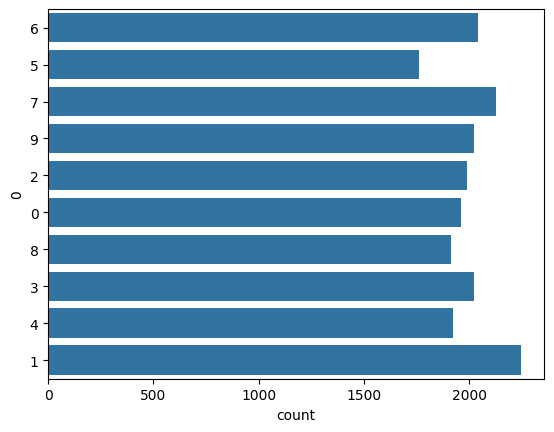

In [51]:
# ¿Estan las clases balanceadas?
sns.countplot(Y)

¿Cómo podríamos ver una observación (una fila en nuestro dataset) de forma que se vea la imagen del número?

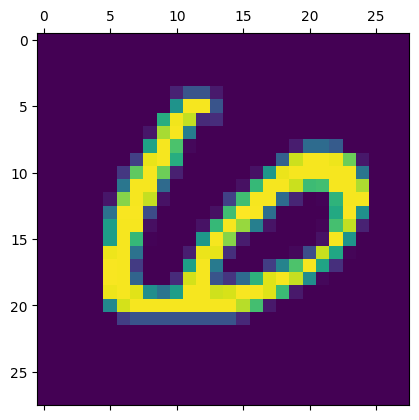

In [52]:
plt.matshow(X.iloc[0,:].values.reshape(28,28))

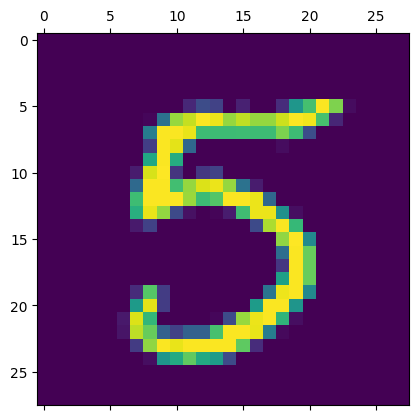

In [53]:
plt.matshow(X.iloc[1,:].values.reshape(28,28))

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


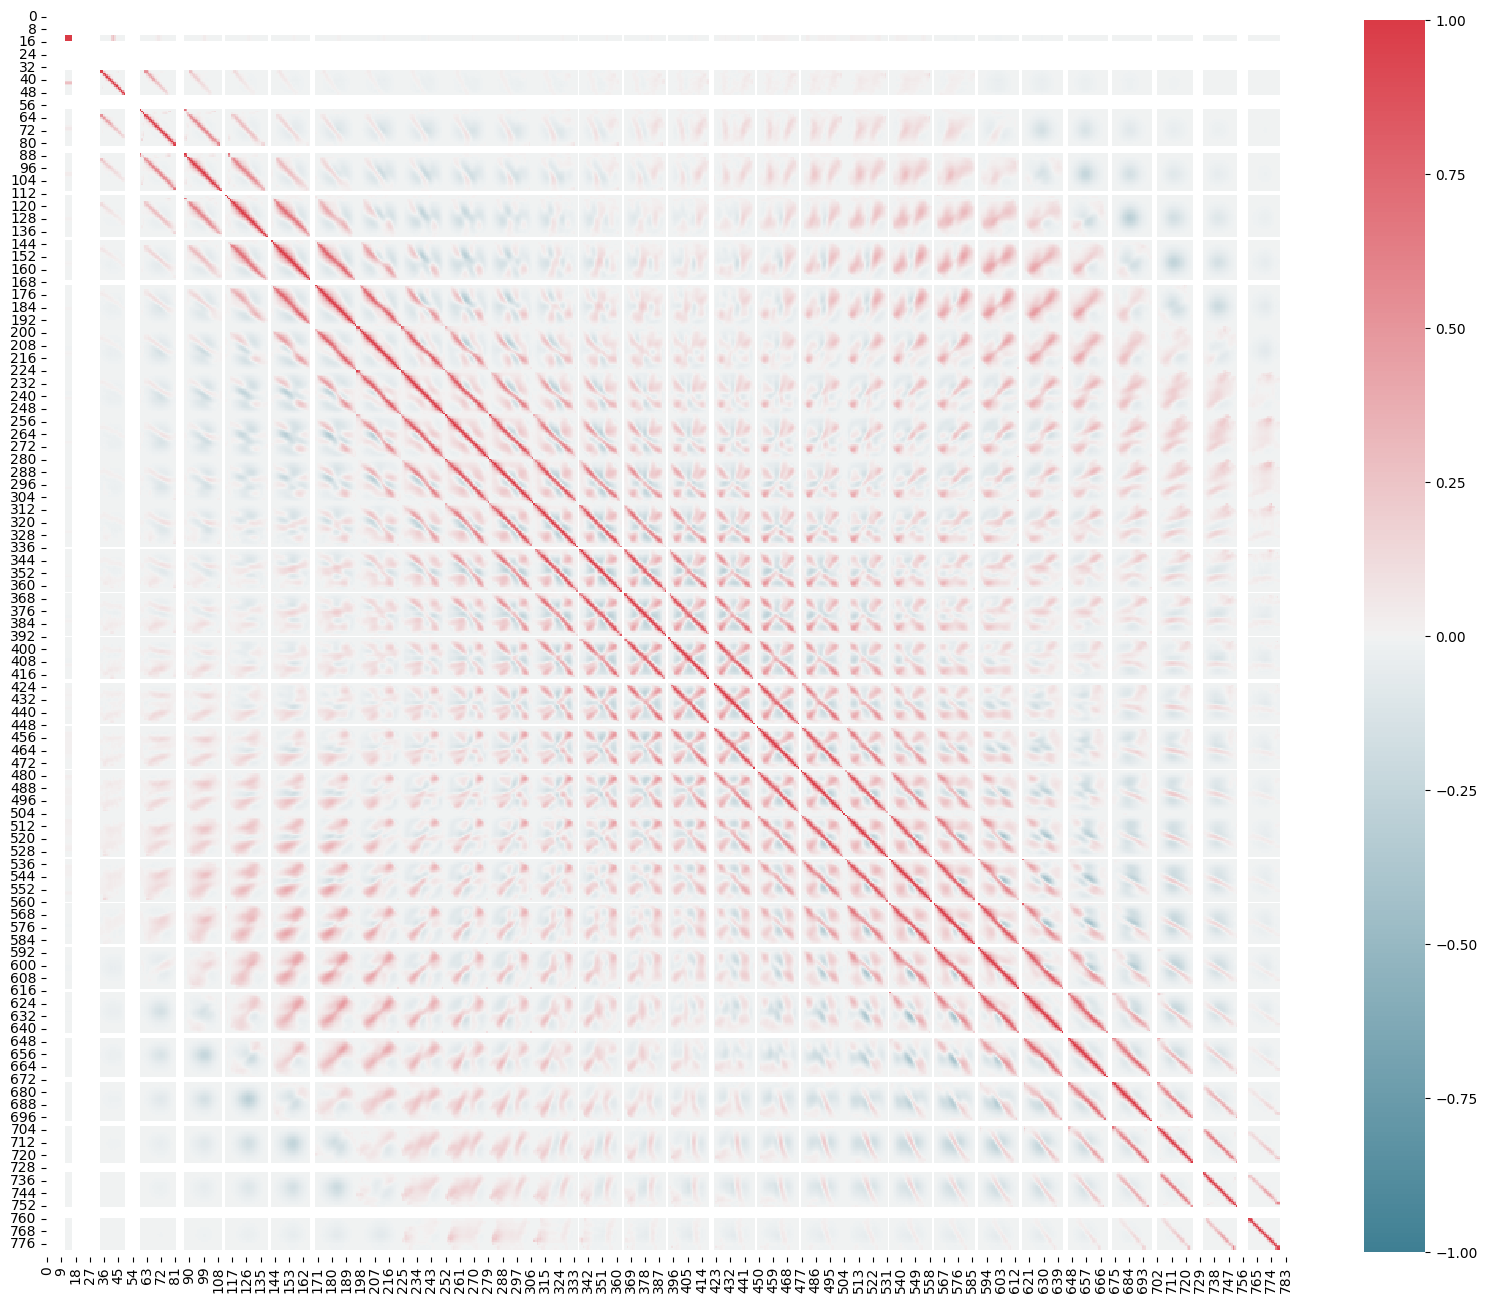

In [54]:
# Correlaciones
corrmat=np.corrcoef(X.T)
plt.show()
plt.figure(figsize=(20,20))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

ax=sns.heatmap(corrmat,vmin=-1, vmax=1,center=0,square=True,cmap=cmap,cbar_kws={"shrink": .8})
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

/usr/local/lib/python3.6/dist-packages/numpy/lib/function_base.py:2534: RuntimeWarning:

invalid value encountered in true_divide

/usr/local/lib/python3.6/dist-packages/numpy/lib/function_base.py:2535: RuntimeWarning:

invalid value encountered in true_divide



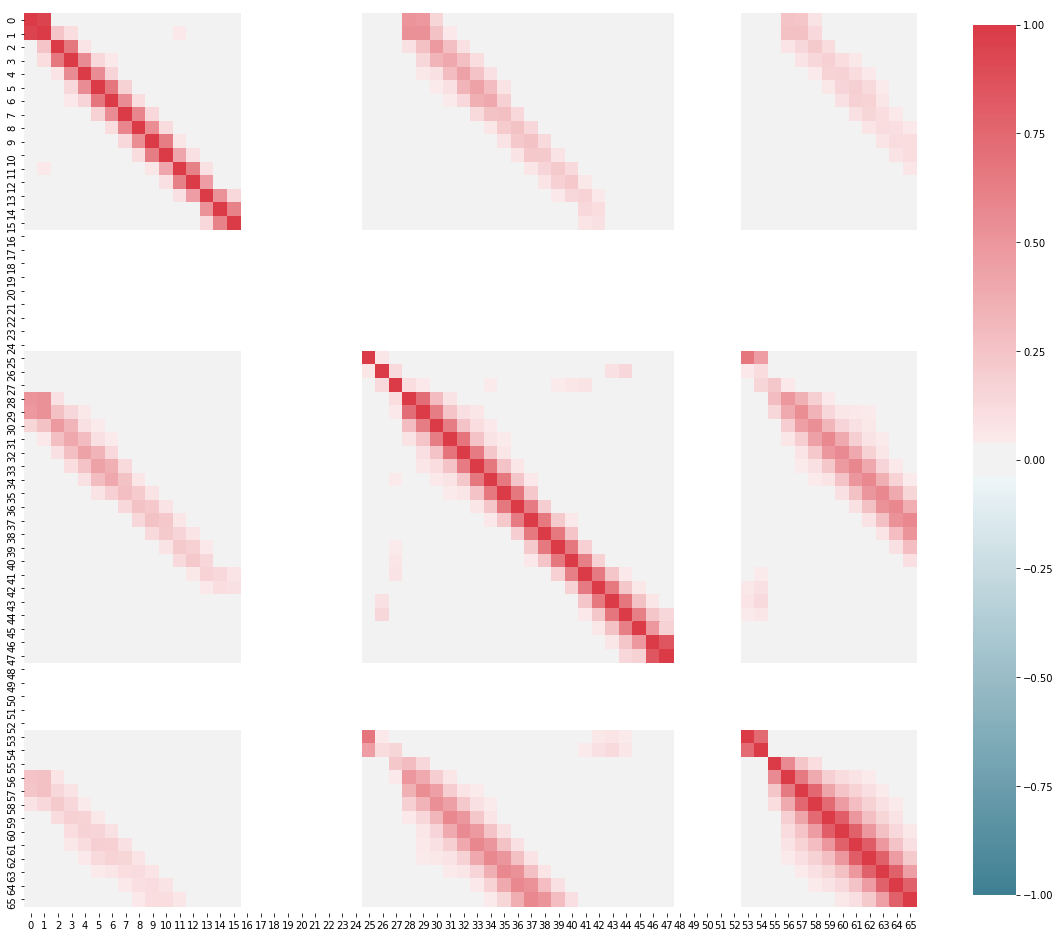

In [ ]:
# Zoom de la estructura de la matriz de correlaciones
corrmat2=np.corrcoef(X.iloc[:,34:100].values.T)
plt.show()
plt.figure(figsize=(20,20))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
ax=sns.heatmap(corrmat2,vmin=-1, vmax=1,center=0,square=True,cmap=cmap,cbar_kws={"shrink": .8})
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()